In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

from sdv.metadata import SingleTableMetadata
from sdv.single_table import TVAESynthesizer



warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.2f}'.format)


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


RAW_PATH      = '../data/weekly_base_bundles_info_202501_202510.csv'

print("The environment is ready.")

The environment is ready.


In [2]:
df = pd.read_csv(RAW_PATH)
df_backup = df.copy()  # Backup copy in memory

print(f" Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

 Loaded: 42,377 rows × 15 columns


In [3]:

df.dropna(subset=['bundle_id', 'bundle_name', 'bundle_type'], inplace=True)


df = df[df['service_class_category'] != 'STAFF']


df = df[~df['bundle_type'].isin(['VAS', 'FLEXI_BUNDLE'])]

df = df[~df['bundle_name'].str.contains("DIY", case=False, na=False)]

df = df[df['usage_type'] != 'FREE']


df.drop('total_duration', axis=1, inplace=True, errors='ignore')
df.drop('usage_type', axis=1, inplace=True, errors='ignore')

n_duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {n_duplicates}")
df.drop_duplicates(inplace=True)


print(f"Final Size: {df.shape}")
print(f"Removed {42377 - len(df):,} Rows in total")

Duplicate Rows: 0
Final Size: (37667, 13)
Removed 4,710 Rows in total


In [4]:
def standardize_validity_to_hours(text):
    if pd.isna(text) or str(text).strip().lower() == 'nan':
        return np.nan
    
    text = str(text).lower()
    
    
    match = re.search(r'\d+(\.\d+)?', text)
    if not match:
        return np.nan 
        
    number = float(match.group())
    
    
    if 'month' in text:
        return number * 30.0 * 24.0  
    elif 'day' in text:
        return number * 24.0        
    elif 'hour' in text:
        return number                
    else:
        
        return number


df['validity_hours_clean'] = df['validity'].apply(standardize_validity_to_hours)


df['validity_hours_log'] = np.log1p(df['validity_hours_clean'])

print("Validity has been converted to hours and processed logarithmically.")
display(df[['validity', 'validity_hours_clean', 'validity_hours_log']].head(5))

Validity has been converted to hours and processed logarithmically.


,validity,validity_hours_clean,validity_hours_log
0,30 Day(s),720.00,6.58
1,30 Day(s),720.00,6.58
2,30 Day(s),720.00,6.58
3,1 Day(s),24.00,3.22
4,30 Day(s),720.00,6.58


In [5]:
df[['validity_hours_clean', 'validity_hours_log']].isnull().sum()

validity_hours_clean    56
validity_hours_log      56
dtype: int64

In [6]:

df.dropna(subset=['validity', 'validity_hours_clean', 'validity_hours_log'], inplace=True)


df.reset_index(drop=True, inplace=True)


print(f"Missing records removed successfully.")
print(f"Remaining record count: {len(df):,}")
print(f"Missing values in validity columns now:\n{df[['validity_hours_clean', 'validity_hours_log']].isnull().sum()}")

Missing records removed successfully.
Remaining record count: 37,611
Missing values in validity columns now:
validity_hours_clean    0
validity_hours_log      0
dtype: int64


In [7]:

# 1. Define processing functions for extraction and cleaning
def extract_price(text):
    """ Extracts price from bundle name using regex """
    if pd.isna(text):
        return None
    match = re.search(r'@(\d+)\s*F', str(text))
    if match:
        return float(match.group(1))
    return None

def clean_price_final(value):
    """
    Cleans price column from currency symbols, spaces, and handles formatting.
    Targeted for VAE where preserving high-value signal is critical.
    """
    if pd.isna(value):
        return np.nan
    
    cleaned = re.sub(r'[^\d.,]', '', str(value))
    
    if ',' in cleaned and '.' in cleaned:
        cleaned = cleaned.replace(',', '')
    elif ',' in cleaned:
        cleaned = cleaned.replace(',', '.')
        
    try:
        return float(cleaned)
    except ValueError:
        return np.nan



print("Start processing prices...")

# a. Extract missing prices from bundle name
mask_missing_price = df['price'].isna()

# Apply extraction function only to rows where price is missing
extracted_prices = df.loc[mask_missing_price, 'bundle_name'].apply(extract_price)

# Count how many values were successfully extracted (not NaN)
filled_from_bundle = extracted_prices.notna().sum()

# Fill values in the original column
df['price'] = df['price'].fillna(extracted_prices)

print(f"Successfully extracted and filled [{filled_from_bundle:,.0f}] missing values from (bundle_name).")

# b. Clean the final price column
print("Cleaning price column...")
df['price_clean'] = df['price'].apply(clean_price_final)

# c. Fill remaining values (that couldn't be extracted) using the Median
df.dropna(subset=['price_clean'], inplace=True)
print(f"Price cleaning complete.")


# d. Logarithmic transformation
df['price_clean_log'] = np.log1p(df['price_clean'])

# Display results for verification
display(df[['price', 'bundle_name', 'price_clean', 'price_clean_log']].head(10))
df[['price_clean']].info()

Start processing prices...
Successfully extracted and filled [18] missing values from (bundle_name).
Cleaning price column...
Price cleaning complete.


,price,bundle_name,price_clean,price_clean_log
0,4000,Forfait 1.6Go 30 jours@4000F,4000.00,8.29
1,690,Forfait appels RCA 2 mins 30 jours@690F,690.00,6.54
2,200,Forfait appels Nigeria 2 mins 30 jours@200F,200.00,5.30
3,215,Forfait 1 jour 170MB@215F,215.00,5.38
4,50050,NDAKO BOX ILLIMITE@50050F,50050.00,10.82
5,1500,Int Bundle ROW 10min 30jours a 1500F,1500.00,7.31
6,590,Forfait appels Guinee Conakry 2 mins 30 jours@590F,590.00,6.38
7,185,Ndeko_11Mins 1 jour@185F,185.00,5.23
8,122,SMS Bundle 3 Days@122F,122.00,4.81
9,50,Promo Back2School 250MB 2 Days @50F,50.00,3.93


<class 'pandas.core.frame.DataFrame'>
Index: 37608 entries, 0 to 37610
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price_clean  37608 non-null  float64
dtypes: float64(1)
memory usage: 587.6 KB


In [8]:


TYPE_MAP = {
    'BUNDLE_VOICE': 'VOICE',
    'BUNDLE_SMS':   'SMS',
    'BUNDLE_DATA':  'DATA',
    'FLEXI_BUNDLE': 'MIXED',   
}



patterns = {
    'DATA': [
        r'(\d[\d,.]*)\s*gb',
        r'(\d[\d,.]*)\s*go',
        r'(\d[\d,.]*)\s*mb',
        r'(\d[\d,.]*)\s*mo',
    ],
    'VOICE': [
        r'(\d[\d,.]*)\s*mn',
        r'(\d[\d,.]*)\s*min',
        r'(\d[\d,.]*)\s*mins',
        r'(\d[\d,.]*)\s*appel',
        r'(\d[\d,.]*)\s*voc',
    ],
    'SMS': [
        r'(\d[\d,.]*)\s*sms',
        r'(\d[\d,.]*)\s*msg',
    ],
}


MIXED_ORDER = ['DATA', 'VOICE', 'SMS']

unlimited_patterns = [
    r'illimit', r'unlimit', r'illimité', r'unlimité',
    r'illimitée', r'unlimitée', r'infini',
]

UNIT_MAP = {
    'DATA': {
        r'(\d[\d,.]*)\s*gb': 'GB',
        r'(\d[\d,.]*)\s*go': 'GB',
        r'(\d[\d,.]*)\s*mb': 'MB',
        r'(\d[\d,.]*)\s*mo': 'MB',
    },
    'VOICE': {
        r'(\d[\d,.]*)\s*mn':    'min',
        r'(\d[\d,.]*)\s*min':   'min',
        r'(\d[\d,.]*)\s*mins':  'min',
        r'(\d[\d,.]*)\s*appel': 'appel',
        r'(\d[\d,.]*)\s*voc':   'voc',
    },
    'SMS': {
        r'(\d[\d,.]*)\s*sms': 'SMS',
        r'(\d[\d,.]*)\s*msg': 'msg',
    },
}




_VOICE_UNITS_RE = re.compile(r'(\d[\d,.]*)\s*(mins?|mn|sec|s)', re.IGNORECASE)

def _parse_complex_voice(text):
    """
    Finds all occurrences of minutes and seconds, sums them up, 
    and converts seconds to decimal minutes.
    Now specifically handles slash formats like '130/15 mn'.
    """
    total_minutes = 0.0
    matched = False
    
    # 1. التقاط النمط المزدوج مثل "130/15 mn" أو "130 / 15 min"
    slash_match = re.search(r'(\d[\d,.]*)\s*/\s*(\d[\d,.]*)\s*(mins?|mn)', text, re.IGNORECASE)
    if slash_match:
        val1 = float(slash_match.group(1).replace(',', '.'))
        val2 = float(slash_match.group(2).replace(',', '.'))
        total_minutes += (val1 + val2)
        matched = True
        
        text = text.replace(slash_match.group(0), '')

    
    hits = _VOICE_UNITS_RE.findall(text)
    if hits:
        matched = True
        for val, unit in hits:
            num = float(val.replace(',', '.'))
            if unit.lower() in ['sec', 's']:
                total_minutes += num / 60  
            else:
                total_minutes += num

    
    if not matched:
        return None

    
    if total_minutes == int(total_minutes):
        return f"{int(total_minutes)}min"
    else:
        return f"{round(total_minutes, 2)}min"


def _search_type(name_lower, btype):
    """Search for the first matching pattern for the bundle type and return value with unit."""
    for pat in patterns.get(btype, []):
        m = re.search(pat, name_lower, re.IGNORECASE)
        if m:
            raw = m.group(1).replace(',', '.')
            unit = UNIT_MAP.get(btype, {}).get(pat, '')
            return f"{raw}{unit}"
    return None



def extract_volume_from_name(bundle_name, bundle_type):
    name_lower = str(bundle_name).lower()
    raw_type   = str(bundle_type).upper().strip()
    btype      = TYPE_MAP.get(raw_type, raw_type)  

    
    for pat in unlimited_patterns:
        if re.search(pat, name_lower, re.IGNORECASE):
            return 'Unlimited'

   
    if btype in ('VOICE', 'MIXED'):
        complex_result = _parse_complex_voice(bundle_name)
        if complex_result:
            return complex_result

    
    if btype == 'MIXED':
        for t in MIXED_ORDER:
            result = _search_type(name_lower, t)
            if result:
                return result
        return None

    
    return _search_type(name_lower, btype)



missing_mask = df['configured_volume'].isna()
print(f"Missing values before processing : {missing_mask.sum()}")


if 'volume_fill_source' not in df.columns:
    df['volume_fill_source'] = 'original'

for idx in df.index[missing_mask]:
    bundle_name = str(df.at[idx, 'bundle_name'])
    bundle_type = str(df.at[idx, 'bundle_type'])
    extracted   = extract_volume_from_name(bundle_name, bundle_type)
    
    if extracted is not None:
        df.at[idx, 'configured_volume'] = extracted
        df.at[idx, 'volume_fill_source'] = 'extracted_from_name'
    else:
        df.at[idx, 'volume_fill_source'] = 'not_found'

still_missing = df['configured_volume'].isna().sum()
filled        = missing_mask.sum() - still_missing

print(f"Successfully filled              : {filled}")
print(f"Still missing (not_found)        : {still_missing}")



print("\nSample of rows that were filled:")
display(df[df['volume_fill_source'] == 'extracted_from_name'][
    ['bundle_name', 'bundle_type', 'configured_volume']
].drop_duplicates('bundle_name').head(25))

print("\nSample of rows that were NOT filled:")
display(df[df['volume_fill_source'] == 'not_found'][
    ['bundle_name', 'bundle_type', 'configured_volume']
].drop_duplicates('bundle_name').head(20))

Missing values before processing : 3077
Successfully filled              : 2020
Still missing (not_found)        : 1057

Sample of rows that were filled:


,bundle_name,bundle_type,configured_volume
32,Forfait EBU 1050 SMS 30 Jours@1100F,BUNDLE_SMS,1050SMS
40,Forfait tous reseaux 67 mins 7 jour@3000F,BUNDLE_VOICE,67min
61,Basic -330 mn - 4950F,BUNDLE_VOICE,330min
83,Forfait tous reseaux 456 mins 30 jour@20500F,BUNDLE_VOICE,456min
99,Forfait MagicVoice 30 jours 318 mins @3500F,BUNDLE_VOICE,318min
113,Forfait appels 5 mins 1 jour@15F,BUNDLE_VOICE,5min
130,Forfait tous reseaux 10 mins 1 jour@450F + BONUS,BUNDLE_VOICE,10min
150,Forfait appels 5 mins 1 jour@25F,BUNDLE_VOICE,5min
153,Illimite 2H par jour pendant 30 Jours@5500F,BUNDLE_DATA,Unlimited
160,Forfait tous reseaux 2 mins 1 jour@100F + BONUS,BUNDLE_VOICE,2min



Sample of rows that were NOT filled:


,bundle_name,bundle_type,configured_volume
8,SMS Bundle 3 Days@122F,BUNDLE_SMS,NaN
20,SMS Bundle 1 Day @26F,BUNDLE_SMS,NaN
87,SMS Bundle 1 Day @41F,BUNDLE_SMS,NaN
105,SMS Bundle 10 Days@507F,BUNDLE_SMS,NaN
176,SMS Bundle 1 day@15F,BUNDLE_SMS,NaN
191,SMS Bundle 5 Days@335F,BUNDLE_SMS,NaN
229,SMS Bundle 2 Days @66F,BUNDLE_SMS,NaN
308,PRO GFU 10-23750F,BUNDLE_VOICE,NaN
589,SMS Bundle 1 day@50F,BUNDLE_SMS,NaN
615,SMS Bundle 3 Days@100F,BUNDLE_SMS,NaN


In [9]:


not_found_df = df[df['volume_fill_source'] == 'not_found'][
    ['bundle_name', 'bundle_type', 'configured_volume']
].copy()

print(f"Total unfilled rows: {len(not_found_df)}")
print("\n" + "="*60)


print("\nbundle_type distribution for unfilled values:")
print(not_found_df['bundle_type'].value_counts())

print("\n" + "="*60)


for btype in not_found_df['bundle_type'].unique():
    sample = not_found_df[not_found_df['bundle_type'] == btype]['bundle_name'].unique()[:15]
    print(f"\n[{btype}] — Sample bundle names:")
    for name in sample:
        print(f"    {name}")

print("\n" + "="*60)


print("\nTop 20 most frequent bundle_names in unfilled rows:")
print(not_found_df['bundle_name'].value_counts().head(20))

Total unfilled rows: 1057


bundle_type distribution for unfilled values:
bundle_type
BUNDLE_SMS      881
BUNDLE_VOICE    171
BUNDLE_DATA       5
Name: count, dtype: int64


[BUNDLE_SMS] — Sample bundle names:
    SMS Bundle 3 Days@122F
    SMS Bundle 1 Day @26F 
    SMS Bundle 1 Day @41F 
    SMS Bundle 10 Days@507F
    SMS Bundle 1 day@15F
    SMS Bundle 5 Days@335F
    SMS Bundle 2 Days @66F 
    SMS Bundle 1 day@50F
    SMS Bundle 3 Days@100F

[BUNDLE_VOICE] — Sample bundle names:
    PRO GFU 10-23750F
    PRO GFU 20-46000F
    PRO GFU 30-67500F
    PRO GFU 15-35250F
    PRO GFU 5-12000F

[BUNDLE_DATA] — Sample bundle names:
    Whatsapp text 1 jour@50F
    Whatsapp text 1 jour@10F 


Top 20 most frequent bundle_names in unfilled rows:
bundle_name
SMS Bundle 3 Days@122F       187
SMS Bundle 5 Days@335F       150
SMS Bundle 1 Day @26F        104
SMS Bundle 2 Days @66F       103
SMS Bundle 10 Days@507F      102
SMS Bundle 1 Day @41F        102
SMS Bundle 1 day@50F          45
SMS Bun

In [10]:

_NAME_DATA_PATTERNS = [
    (r'(\d[\d,.]*)\s*gb', 'GB'),
    (r'(\d[\d,.]*)\s*go', 'GB'),
    (r'(\d[\d,.]*)\s*mb', 'MB'),
    (r'(\d[\d,.]*)\s*mo', 'MB'),
]

TYPE_MAP = {
    'BUNDLE_VOICE': 'VOICE',
    'BUNDLE_SMS':   'SMS',
    'BUNDLE_DATA':  'DATA',
}

_VOICE_COMPOUND_RE = re.compile(
    r'(\d[\d,.]*)\s*(?:mins?|mn)[^,]*?(\d[\d,.]*)\s*(?:sec|s)\b',
    re.IGNORECASE
)

def _unit_from_name(bundle_name):
    """Infers the unit from the bundle name if not explicitly stated"""
    name_lower = str(bundle_name).lower()
    for pat, unit in _NAME_DATA_PATTERNS:
        if re.search(pat, name_lower, re.IGNORECASE):
            return unit
    return 'MB'  

def parse_volumes(row):
    """
    Parses volume and returns 4 values: 
    (MB volume, Minutes volume, SMS volume, Unlimited indicator)
    """
    volume_str = row['configured_volume']
    bundle_type = row['bundle_type']
    bundle_name = row['bundle_name']
    
   
    vol_MB, vol_min, vol_SMS = 0.0, 0.0, 0.0
    is_unlimited = 0
    
    if pd.isna(volume_str):
        return np.nan, np.nan, np.nan, 0

    v = str(volume_str).strip().lower()
    btype = TYPE_MAP.get(str(bundle_type).upper().strip(), str(bundle_type).upper().strip())

    
    if v in ('unlimited', 'illimité', 'illimitée', 'unlimitée', 'infini'):
        is_unlimited = 1
        
        if btype == 'VOICE':
            vol_min = -1.0
        elif btype == 'SMS':
            vol_SMS = -1.0
        elif btype == 'DATA':
            vol_MB = -1.0
        else:
            # Try to infer from name if type is unclear
            name_lower = str(bundle_name).lower()
            if 'sms' in name_lower: vol_SMS = -1.0
            elif 'voix' in name_lower or 'min' in name_lower: vol_min = -1.0
            else: vol_MB = -1.0
            
        return vol_MB, vol_min, vol_SMS, is_unlimited

    
    compound = _VOICE_COMPOUND_RE.search(v)
    if compound:
        mins = float(compound.group(1).replace(',', '.'))
        secs = float(compound.group(2).replace(',', '.'))
        vol_min = round(mins + secs / 60, 4)
        return vol_MB, vol_min, vol_SMS, is_unlimited

    
    m = re.search(r'(\d[\d,.]*)\s*([a-zA-Z]*)', v.replace('\xa0', ' '))
    if not m:
        return np.nan, np.nan, np.nan, is_unlimited

    num_str = m.group(1).replace(' ', '').replace(',', '.')
    unit_str = m.group(2).strip().lower()

    try:
        num = float(num_str)
    except ValueError:
        return np.nan, np.nan, np.nan, is_unlimited

    
    actual_unit = unit_str.upper()
    if actual_unit in ('GB', 'GO', 'G'):
        vol_MB = round(num * 1024, 4)
    elif actual_unit in ('MB', 'MO'):
        vol_MB = num
    elif actual_unit in ('MIN', 'MINS', 'MN'):
        vol_min = num
    elif actual_unit == 'SMS':
        vol_SMS = int(num)
    elif actual_unit == '':
        # If unit is missing, rely on bundle type
        if btype == 'VOICE': vol_min = num
        elif btype == 'SMS': vol_SMS = int(num)
        else: 
            inferred = _unit_from_name(bundle_name)
            if inferred == 'GB': vol_MB = round(num * 1024, 4)
            elif inferred == 'MB': vol_MB = num
            else: vol_MB = num
    else:
        vol_MB = num # Default

    return vol_MB, vol_min, vol_SMS, is_unlimited




parsed_columns = df.apply(parse_volumes, axis=1, result_type='expand')
parsed_columns.columns = ['volume_MB', 'volume_min', 'volume_SMS', 'is_unlimited_volume']


df = pd.concat([df, parsed_columns], axis=1)




q95_MB = df.loc[df['volume_MB'] > 0, 'volume_MB'].quantile(0.95)
q95_min = df.loc[df['volume_min'] > 0, 'volume_min'].quantile(0.95)
q95_SMS = df.loc[df['volume_SMS'] > 0, 'volume_SMS'].quantile(0.95)


q95_MB = q95_MB if pd.notna(q95_MB) else 999999
q95_min = q95_min if pd.notna(q95_min) else 999999
q95_SMS = q95_SMS if pd.notna(q95_SMS) else 999999


df.loc[df['volume_MB'] == -1.0, 'volume_MB'] = q95_MB
df.loc[df['volume_min'] == -1.0, 'volume_min'] = q95_min
df.loc[df['volume_SMS'] == -1.0, 'volume_SMS'] = q95_SMS



display_cols = ['bundle_type', 'configured_volume', 'volume_MB', 'volume_min', 'volume_SMS', 'is_unlimited_volume']
display(df[df['configured_volume'].notna()][display_cols].head(15))

,bundle_type,configured_volume,volume_MB,volume_min,volume_SMS,is_unlimited_volume
0,BUNDLE_DATA,1.61,1648.64,0.00,0.00,0.00
1,INT_BUNDLE_VOICE,2MIN,0.00,2.00,0.00,0.00
2,INT_BUNDLE_VOICE,2MIN,0.00,2.00,0.00,0.00
3,BUNDLE_DATA,170,170.00,0.00,0.00,0.00
4,BUNDLE_DATA,Unlimited,153600.00,0.00,0.00,1.00
5,INT_BUNDLE_VOICE,10MIN,0.00,10.00,0.00,0.00
6,INT_BUNDLE_VOICE,2MIN,0.00,2.00,0.00,0.00
7,BUNDLE_VOICE,11min,0.00,11.00,0.00,0.00
9,BUNDLE_DATA,250MB,250.00,0.00,0.00,0.00
10,BUNDLE_DATA,Unlimited,153600.00,0.00,0.00,1.00


In [11]:

df['volume_fill_source'] = 'original'


missing_mask = df['volume_MB'].isna()


median_MB = df.loc[df['volume_MB'] > 0, 'volume_MB'].median()
median_min = df.loc[df['volume_min'] > 0, 'volume_min'].median()
median_SMS = df.loc[df['volume_SMS'] > 0, 'volume_SMS'].median()


median_MB = median_MB if pd.notna(median_MB) else 0.0
median_min = median_min if pd.notna(median_min) else 0.0
median_SMS = median_SMS if pd.notna(median_SMS) else 0.0

print("Calculated medians per category:")
print(f"MB: {median_MB} | min: {median_min} | SMS: {median_SMS}")


df.loc[missing_mask, ['volume_MB', 'volume_min', 'volume_SMS']] = 0.0


btypes = df['bundle_type'].astype(str).str.upper()




voice_mask = missing_mask & btypes.str.contains('VOICE')
df.loc[voice_mask, 'volume_min'] = median_min
df.loc[voice_mask, 'volume_fill_source'] = 'imputed_min_median'


data_mask = missing_mask & btypes.str.contains('DATA')
df.loc[data_mask, 'volume_MB'] = median_MB
df.loc[data_mask, 'volume_fill_source'] = 'imputed_MB_median'


sms_mask = missing_mask & btypes.str.contains('SMS')
df.loc[sms_mask, 'volume_SMS'] = median_SMS
df.loc[sms_mask, 'volume_fill_source'] = 'imputed_SMS_median'


other_mask = missing_mask & ~voice_mask & ~data_mask & ~sms_mask
df.loc[other_mask, 'volume_fill_source'] = 'imputed_zero_unknown'



print(f"\nRemaining missing values in volume_MB: {df['volume_MB'].isna().sum()}")


display_cols = ['bundle_type', 'configured_volume', 'volume_MB', 'volume_min', 'volume_SMS', 'volume_fill_source']
display(df[df['volume_fill_source'] != 'original'][display_cols].head(10))

Calculated medians per category:
MB: 1617.92 | min: 19.0 | SMS: 100.0

Remaining missing values in volume_MB: 0


,bundle_type,configured_volume,volume_MB,volume_min,volume_SMS,volume_fill_source
8,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
20,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
87,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
105,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
151,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
176,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
191,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
221,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
229,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median
231,BUNDLE_SMS,NaN,0.00,0.00,100.00,imputed_SMS_median


In [12]:

volume_cols = ['volume_MB', 'volume_min', 'volume_SMS']


for col in volume_cols:
    df[f'{col}_log'] = np.log1p(df[col])


display_cols = ['volume_MB', 'volume_MB_log', 'volume_min', 'volume_min_log', 'volume_SMS', 'volume_SMS_log']
display(df[display_cols].head(10))

,volume_MB,volume_MB_log,volume_min,volume_min_log,volume_SMS,volume_SMS_log
0,1648.64,7.41,0.00,0.00,0.00,0.00
1,0.00,0.00,2.00,1.10,0.00,0.00
2,0.00,0.00,2.00,1.10,0.00,0.00
3,170.00,5.14,0.00,0.00,0.00,0.00
4,153600.00,11.94,0.00,0.00,0.00,0.00
5,0.00,0.00,10.00,2.40,0.00,0.00
6,0.00,0.00,2.00,1.10,0.00,0.00
7,0.00,0.00,11.00,2.48,0.00,0.00
8,0.00,0.00,0.00,0.00,100.00,4.62
9,250.00,5.53,0.00,0.00,0.00,0.00


 --- Checking Revenue Processing Results --- 
Found 133 records with negative revenue. Dropping them...

Statistical Comparison (Before and After Dropping):


,Original (With Negatives),Cleaned (Dropped Negatives)
count,37608.00,37475.00
mean,2201423.92,2209265.04
std,10186227.68,10203435.85
min,-18300.00,0.00
25%,4992.00,5000.00
50%,39000.00,39650.00
75%,348712.48,351620.05
max,190846301.35,190846301.35


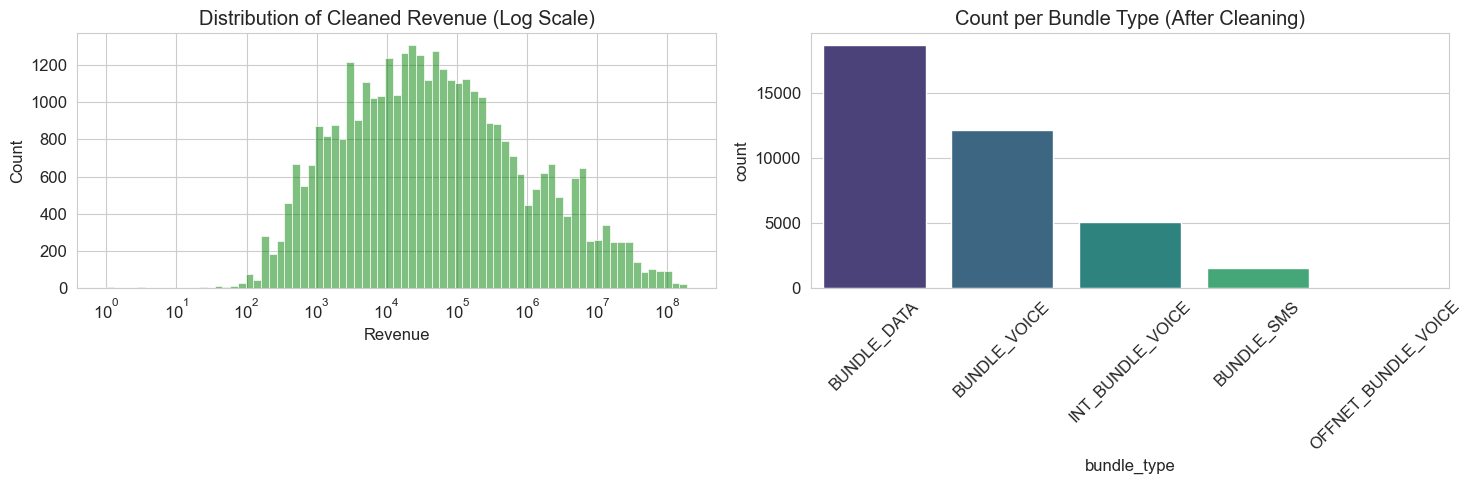


   - Number of records with zero value: 8
   - Final dataset size: 37475 rows


In [13]:

print(" --- Checking Revenue Processing Results --- ")


negative_count = (df['total_rev'] < 0).sum()
print(f"Found {negative_count} records with negative revenue. Dropping them...")


desc_before = df['total_rev'].describe()


df = df[df['total_rev'] >= 0].copy()


df['total_rev_clean'] = df['total_rev']


print("\nStatistical Comparison (Before and After Dropping):")
comparison = pd.DataFrame({
    'Original (With Negatives)': desc_before,
    'Cleaned (Dropped Negatives)': df['total_rev_clean'].describe()
})
display(comparison)


plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
sns.histplot(df['total_rev_clean'], kde=True, color='green', log_scale=True)
plt.title('Distribution of Cleaned Revenue (Log Scale)')
plt.xlabel('Revenue')


plt.subplot(1, 2, 2)
sns.countplot(data=df, x='bundle_type', palette='viridis', order=df['bundle_type'].value_counts().index)
plt.title('Count per Bundle Type (After Cleaning)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


zeros_count = (df['total_rev_clean'] == 0).sum()
print(f"\n   - Number of records with zero value: {zeros_count}")
print(f"   - Final dataset size: {df.shape[0]} rows")

In [14]:
zeros_df = df[df['total_rev_clean'] == 0]
print("Records with Zero Revenue:")
display(zeros_df[['bundle_name', 'bundle_type', 'price_clean', 'total_rev_clean']])


df = df[df['total_rev_clean'] > 0].copy()

print(f"\n Zeros have been removed. Final data size: {df.shape[0]} rows.")

Records with Zero Revenue:


,bundle_name,bundle_type,price_clean,total_rev_clean
4150,Forfait Mifi 7 jours 13GB@5500F,BUNDLE_DATA,5500.00,0.00
5358,NDAKO BOX 150GB@35000F,BUNDLE_DATA,35000.00,0.00
7579,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.00,0.00
10895,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,35000.00,0.00
18139,FORFAIT Mifi 37538 MB 7 Jours@10000F,BUNDLE_DATA,10000.00,0.00
20720,FORFAIT Mifi 37538 MB 7 Jours@10000F,BUNDLE_DATA,10000.00,0.00
21471,FORFAIT Mifi 37538 MB 7 Jours@10000F,BUNDLE_DATA,10000.00,0.00
34501,Voice Bundle 31 Days @5742F 224min,BUNDLE_VOICE,5742.00,0.00



 Zeros have been removed. Final data size: 37467 rows.


In [15]:
df['total_rev_clean_log'] = np.log1p(df['total_rev_clean'])
display(df[['total_rev_clean', 'total_rev_clean_log']].head(10))

,total_rev_clean,total_rev_clean_log
0,36000.00,10.49
1,3450.00,8.15
2,400.00,5.99
3,124060.00,11.73
4,200200.00,12.21
5,37500.00,10.53
6,56640.00,10.94
7,17161358.36,16.66
8,10018029.99,16.12
9,10850.00,9.29


In [16]:
def fill_service_class(row):
    
    if pd.notna(row['service_class_category']):
        return str(row['service_class_category']).upper().strip()
    
    name = str(row['bundle_name']).lower()
    
    
    if any(word in name for word in ['corpo', 'business', 'ebu', 'post', 'fixe']):
        return 'POSTPAID'
    
    if any(word in name for word in ['hybrid', 'mixte']):
        return 'HYBRID'
    
    
    return 'PREPAID'


df['service_class_category'] = df.apply(fill_service_class, axis=1)


print(df['service_class_category'].value_counts())


service_class_category
PREPAID     27919
HYBRID       9483
POSTPAID       65
Name: count, dtype: int64


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37467 entries, 0 to 37610
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   week_number             37467 non-null  int64  
 1   year_number             37467 non-null  int64  
 2   bundle_id               37467 non-null  object 
 3   bundle_name             37467 non-null  object 
 4   bundle_type             37467 non-null  object 
 5   validity                37467 non-null  object 
 6   price                   37467 non-null  object 
 7   configured_volume       36543 non-null  object 
 8   service_class_category  37467 non-null  object 
 9   total_rev               37467 non-null  float64
 10  total_subscriptions     37467 non-null  int64  
 11  total_sessions          37467 non-null  int64  
 12  unique_users            37467 non-null  int64  
 13  validity_hours_clean    37467 non-null  float64
 14  validity_hours_log      37467 non-null  flo

In [ ]:
df.to_csv('clean_dataset.csv', index=False)

In [ ]:
columns_for_training = [
    'bundle_type', 
    'service_class_category', 
    'is_unlimited_volume',
    'volume_MB_log',
    'volume_min_log',
    'volume_SMS_log',
    'validity_hours_log',
    'price_clean_log'
]
df_train = df[columns_for_training]
df_train.to_csv('training_dataset.csv', index=False)
df_train = df[columns_for_training].copy()

In [ ]:
# columns_for_training = [
#     'bundle_type',
#     'service_class_category',
#     'is_unlimited_volume',
#     'volume_MB_log',
#     'volume_min_log',
#     'volume_SMS_log',
#     'validity_hours_log',
#     'price_clean_log'
# ]

# df_train = df_train[columns_for_training]

df_train['is_unlimited_volume'] = df_train['is_unlimited_volume'].astype(bool)


assert df_train.isna().sum().sum() == 0, "Warning: There are still missing values in the training data!"


print("Training data shape:", df_train.shape)
display(df_train.head(5))

Training data shape: (37467, 8)


,bundle_type,service_class_category,is_unlimited_volume,volume_MB_log,volume_min_log,volume_SMS_log,validity_hours_log,price_clean_log
0,BUNDLE_DATA,PREPAID,False,7.408312,0.000000,0.0,6.580639,8.294300
1,INT_BUNDLE_VOICE,PREPAID,False,0.000000,1.098612,0.0,6.580639,6.538140
2,INT_BUNDLE_VOICE,PREPAID,False,0.000000,1.098612,0.0,6.580639,5.303305
3,BUNDLE_DATA,PREPAID,False,5.141664,0.000000,0.0,3.218876,5.375278
4,BUNDLE_DATA,PREPAID,True,11.942114,0.000000,0.0,6.580639,10.820798


In [ ]:

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_train)


print("Detected Metadata:")
print(metadata.to_dict())

Detected Metadata:
{'columns': {'bundle_type': {'sdtype': 'categorical'}, 'service_class_category': {'sdtype': 'categorical'}, 'is_unlimited_volume': {'sdtype': 'categorical'}, 'volume_MB_log': {'sdtype': 'numerical'}, 'volume_min_log': {'sdtype': 'numerical'}, 'volume_SMS_log': {'sdtype': 'numerical'}, 'validity_hours_log': {'sdtype': 'numerical'}, 'price_clean_log': {'sdtype': 'numerical'}}, 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}


In [ ]:

print("Initializing TVAE Synthesizer...")

synthesizer = TVAESynthesizer(
    metadata,
    epochs=300,        
    batch_size=500,    
    cuda=True         
)

print("Training the model... (This may take a few minutes depending on your GPU)")
synthesizer.fit(df_train)


synthesizer.save('tvae_bundle_model.pkl')
print("Training complete and model saved as 'tvae_bundle_model.pkl'!")

Initializing TVAE Synthesizer...
Training the model... (This may take a few minutes depending on your GPU)
Training complete and model saved as 'tvae_bundle_model.pkl'!


In [ ]:

num_new_bundles = 5000
print(f"Generating {num_new_bundles} new synthetic bundles...")


synthetic_raw = synthesizer.sample(num_rows=num_new_bundles)

print("Raw Generation Complete. Sample:")
display(synthetic_raw.head(3))

Generating 5000 new synthetic bundles...
Raw Generation Complete. Sample:


,bundle_type,service_class_category,is_unlimited_volume,volume_MB_log,volume_min_log,volume_SMS_log,validity_hours_log,price_clean_log
0,BUNDLE_DATA,PREPAID,False,6.029261,0.000452,0.000000,3.218572,5.995995
1,BUNDLE_DATA,PREPAID,False,4.974601,0.001537,0.000168,5.130859,6.273827
2,BUNDLE_DATA,PREPAID,False,5.165308,0.000000,0.000000,5.128834,6.507243


In [ ]:


synthetic_final = synthetic_raw.copy()


synthetic_final['volume_MB'] = np.expm1(synthetic_final['volume_MB_log'])
synthetic_final['volume_min'] = np.expm1(synthetic_final['volume_min_log'])
synthetic_final['volume_SMS'] = np.expm1(synthetic_final['volume_SMS_log'])
synthetic_final['validity_hours'] = np.expm1(synthetic_final['validity_hours_log'])
synthetic_final['price_clean'] = np.expm1(synthetic_final['price_clean_log'])


synthetic_final['volume_MB'] = synthetic_final['volume_MB'].round(0).astype(int)
synthetic_final['volume_min'] = synthetic_final['volume_min'].round(0).astype(int)
synthetic_final['volume_SMS'] = synthetic_final['volume_SMS'].round(0).astype(int)
synthetic_final['validity_hours'] = synthetic_final['validity_hours'].round(0).astype(int)


synthetic_final['price_clean'] = synthetic_final['price_clean'].round(2)


synthetic_final.rename(columns={'price_clean': 'baseline_price'}, inplace=True)


cols_to_drop = [col for col in synthetic_final.columns if col.endswith('_log')]
synthetic_final.drop(columns=cols_to_drop, inplace=True)

print("Post-processing complete!")

Post-processing complete!


In [ ]:

final_columns_order = [
    'bundle_type',
    'service_class_category',
    'is_unlimited_volume',
    'volume_MB',
    'volume_min',
    'volume_SMS',
    'validity_hours',
    'baseline_price'
]

synthetic_bundles_ready = synthetic_final[final_columns_order]

print("=== FINAL SYNTHETIC BUNDLES (READY FOR PRICING & POPULARITY MODELS) ===")
display(synthetic_bundles_ready.head(10))


synthetic_bundles_ready.to_csv('synthetic_telecom_bundles.csv', index=False)

=== FINAL SYNTHETIC BUNDLES (READY FOR PRICING & POPULARITY MODELS) ===


,bundle_type,service_class_category,is_unlimited_volume,volume_MB,volume_min,volume_SMS,validity_hours,baseline_price
0,BUNDLE_DATA,PREPAID,False,414,0,0,24,400.82
1,BUNDLE_DATA,PREPAID,False,144,0,0,168,529.50
2,BUNDLE_DATA,PREPAID,False,174,0,0,168,668.98
3,INT_BUNDLE_VOICE,PREPAID,False,0,5,0,720,746.26
4,BUNDLE_VOICE,PREPAID,False,0,6,0,24,97.20
5,BUNDLE_DATA,PREPAID,False,13067,0,0,168,4042.26
6,BUNDLE_VOICE,PREPAID,False,0,821,0,168,5114.20
7,INT_BUNDLE_VOICE,PREPAID,False,0,2,0,721,327.12
8,BUNDLE_VOICE,PREPAID,False,0,63,0,168,925.38
9,BUNDLE_DATA,PREPAID,False,6534,0,0,168,2695.25


In [ ]:
from sdv.evaluation.single_table import evaluate_quality



print("Running SDV Quality Report...")
quality_report = evaluate_quality(
    real_data=df_train,
    synthetic_data=synthetic_raw,
    metadata=metadata
)



Running SDV Quality Report...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 94.94it/s]|
Column Shapes Score: 80.02%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 30.39it/s]|
Column Pair Trends Score: 85.49%

Overall Score (Average): 82.75%



In [ ]:

duplicates = pd.merge(df_train, synthetic_raw, how='inner')
exact_match_ratio = (len(duplicates) / len(synthetic_raw)) * 100

print(f"Exact Matches: {exact_match_ratio:.2f}%")

std_comparison = pd.DataFrame({
    'Real_Std': df_train[['volume_MB_log', 'price_clean_log']].std(),
    'Synthetic_Std': synthetic_raw[['volume_MB_log', 'price_clean_log']].std()
})
display(std_comparison)

Exact Matches: 0.00%


,Real_Std,Synthetic_Std
volume_MB_log,4.245164,4.231891
price_clean_log,1.586201,1.303057


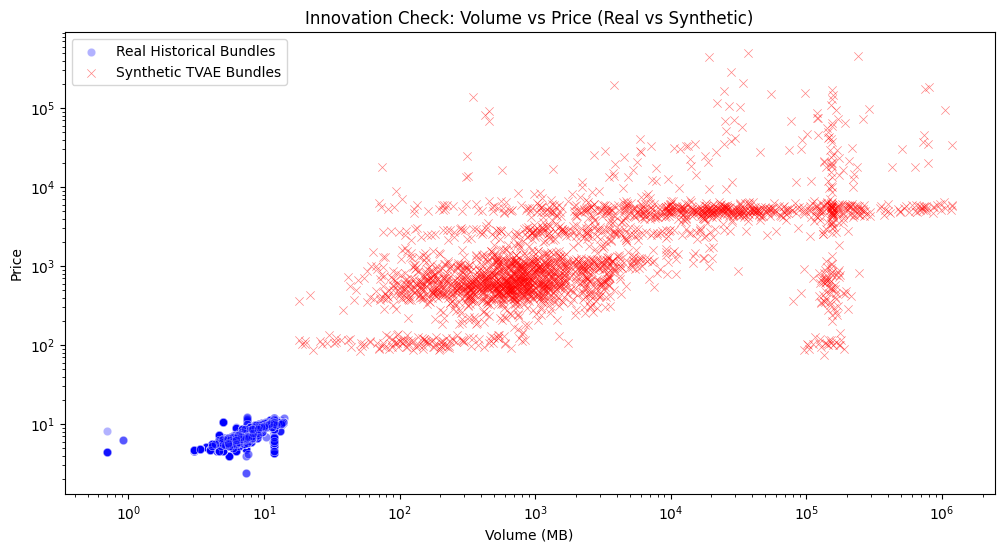

In [ ]:


plt.figure(figsize=(12, 6))


sns.scatterplot(
    data=df_train,
    x='volume_MB_log', y='price_clean_log',
    color='blue', alpha=0.3, label='Real Historical Bundles'
)


sns.scatterplot(
    data=synthetic_bundles_ready,
    x='volume_MB', y='baseline_price',
    color='red', alpha=0.5, marker='x', label='Synthetic TVAE Bundles'
)

plt.xscale('log') 
plt.yscale('log')
plt.title('Innovation Check: Volume vs Price (Real vs Synthetic)')
plt.xlabel('Volume (MB)')
plt.ylabel('Price')
plt.legend()
plt.show()

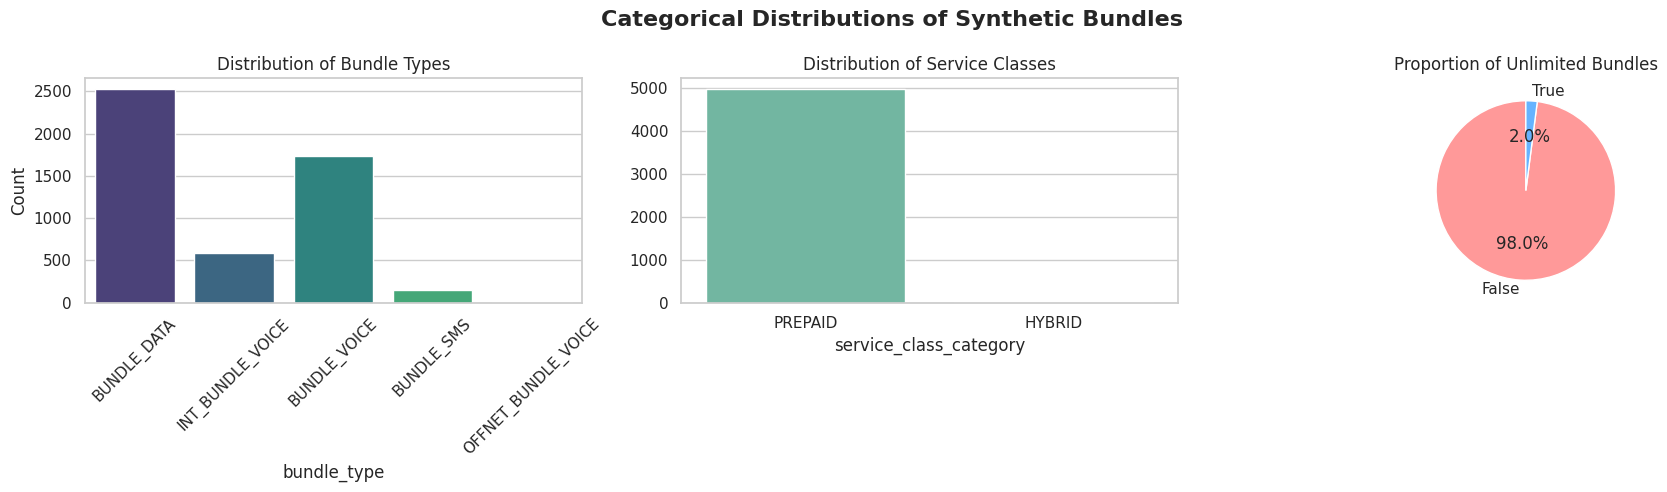

In [ ]:

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorical Distributions of Synthetic Bundles', fontsize=16, fontweight='bold')


sns.countplot(data=synthetic_bundles_ready, x='bundle_type', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Bundle Types')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count')

sns.countplot(data=synthetic_bundles_ready, x='service_class_category', ax=axes[1], palette='Set2')
axes[1].set_title('Distribution of Service Classes')
axes[1].set_ylabel('')


synthetic_bundles_ready['is_unlimited_volume'].value_counts().plot.pie(
    ax=axes[2], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff']
)
axes[2].set_title('Proportion of Unlimited Bundles')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

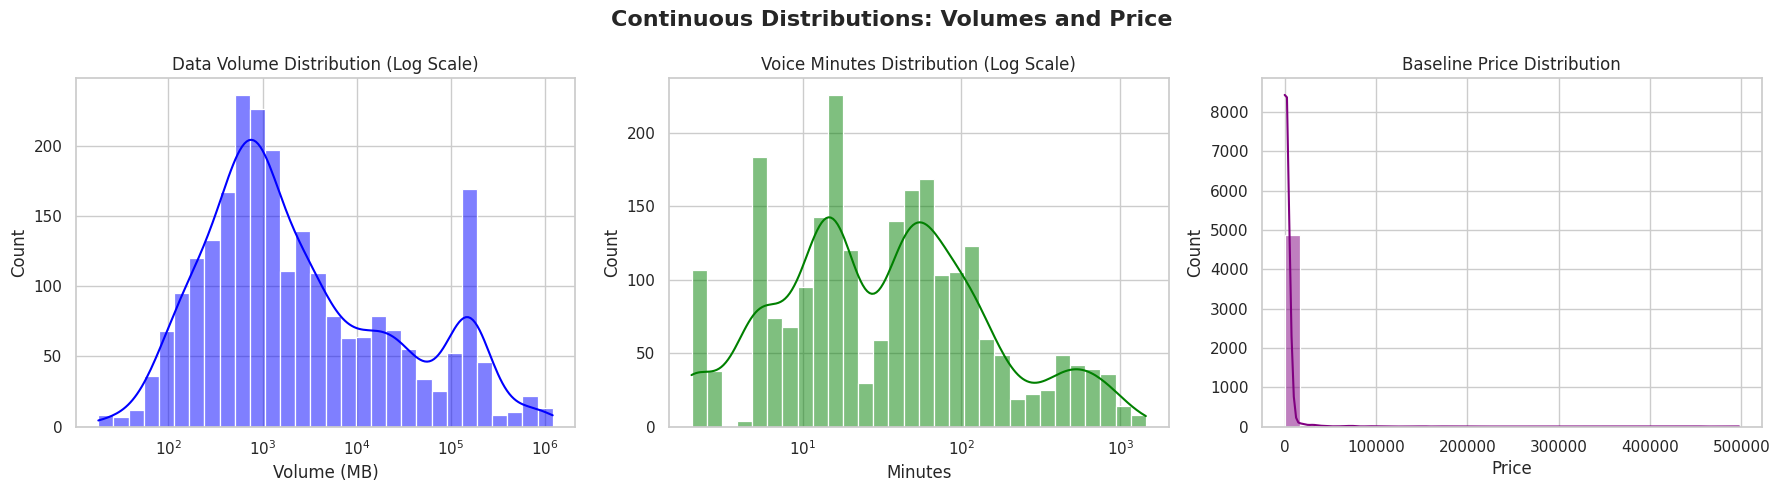

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Continuous Distributions: Volumes and Price', fontsize=16, fontweight='bold')


sns.histplot(data=synthetic_bundles_ready[synthetic_bundles_ready['volume_MB'] > 0],
             x='volume_MB', bins=30, kde=True, ax=axes[0], color='blue', log_scale=True)
axes[0].set_title('Data Volume Distribution (Log Scale)')
axes[0].set_xlabel('Volume (MB)')


sns.histplot(data=synthetic_bundles_ready[synthetic_bundles_ready['volume_min'] > 0],
             x='volume_min', bins=30, kde=True, ax=axes[1], color='green', log_scale=True)
axes[1].set_title('Voice Minutes Distribution (Log Scale)')
axes[1].set_xlabel('Minutes')


sns.histplot(data=synthetic_bundles_ready,
             x='baseline_price', bins=30, kde=True, ax=axes[2], color='purple')
axes[2].set_title('Baseline Price Distribution')
axes[2].set_xlabel('Price')

plt.tight_layout()
plt.show()

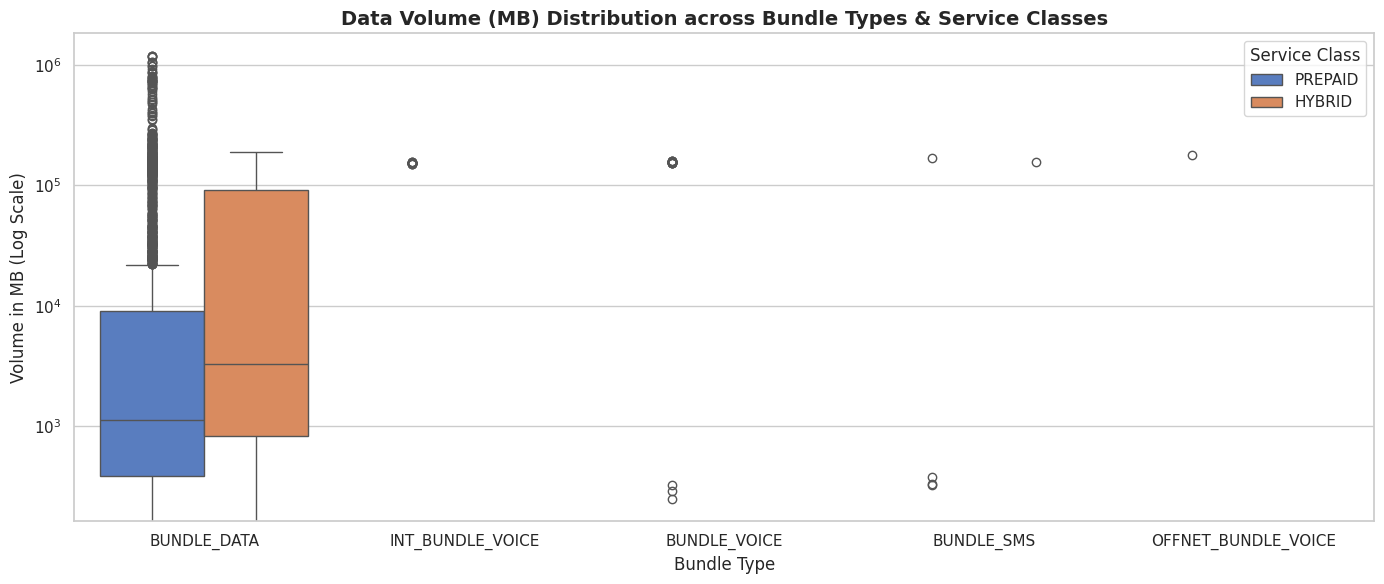

--- Summary Statistics for Synthetic Volumes (MB) by Bundle Type ---


,count,mean,std,min,25%,50%,75%,max
bundle_type,,,,,,,,
BUNDLE_DATA,2527.0,33995.09,112825.54,0.0,394.0,1143.0,9168.5,1198080.0
BUNDLE_SMS,146.0,2238.37,19011.81,0.0,0.0,0.0,0.0,169261.0
BUNDLE_VOICE,1731.0,1353.13,14472.43,0.0,0.0,0.0,0.0,158798.0
INT_BUNDLE_VOICE,583.0,3685.55,23517.43,0.0,0.0,0.0,0.0,156337.0
OFFNET_BUNDLE_VOICE,13.0,13729.15,49501.17,0.0,0.0,0.0,0.0,178479.0


In [ ]:
plt.figure(figsize=(14, 6))


sns.boxplot(data=synthetic_bundles_ready,
            x='bundle_type',
            y='volume_MB',
            hue='service_class_category',
            palette='muted')


plt.yscale('log')
plt.title('Data Volume (MB) Distribution across Bundle Types & Service Classes', fontsize=14, fontweight='bold')
plt.ylabel('Volume in MB (Log Scale)')
plt.xlabel('Bundle Type')
plt.legend(title='Service Class')

plt.tight_layout()
plt.show()


print("--- Summary Statistics for Synthetic Volumes (MB) by Bundle Type ---")
display(synthetic_bundles_ready.groupby('bundle_type')['volume_MB'].describe().round(2))